# PING PONG SIMULATION

In [22]:
import numpy as np
import numpy.typing as npt
#
# PHYSICS SECTION
#
TABLE_LENGTH = 2.74 #m
TABLE_WIDTH  = 1.525 #m
GRAVITY = 9.81
TRANSLATIONAL_DRAG = 0.01
MAGNUS_STRENGTH = 0.08
ANGULAR_DRAG_COEFF = 0.47
MAX_TRANS_VELOCITY = 75.0
MAX_ANGULAR_VELOCITY = 25.0
BALL_RADIUS = 0.02
MARGIN_BALL = 0.01 # Margin to consider the ball has hit the net, to avoid numerical issues
FRICTION_COEFF = 0.1 # Coefficient of friction for the bounce, this is a simplified model and can be adjusted for realism
BOUNCE_COEFF = 0.95 # Coefficient of restitution for the bounce, this is a simplified model and can be adjusted for realism
INERTIA_FACTOR = 1.1

# MATH SECTION

In [23]:
# MATH SECTION

vec3 = npt.NDArray[np.float32]

def vec3_create(x : float = 0, y : float = 0, z : float = 0) -> vec3:
    return np.array([x, y, z], dtype=np.float32)

def dot(a : vec3, b : vec3) -> float:
    return np.dot(a, b)

def cross(a : vec3, b : vec3) -> vec3:
    return np.cross(a, b)

def magnitude(v : vec3) -> float:
    return np.linalg.norm(v)

#STRUCTURES
class Ball: #SIMPLE STRUCTURE TO HOLD BALL STATE
    def __init__(self, pos : vec3, vel : vec3, angular_vel : vec3):
        self.pos = pos
        self.vel = vel
        self.angular_vel = angular_vel
        
class AABB: #AXIS ALIGNED BOUNDING BOX, FOR COLLISION DETECTION
    def __init__(self, min_bound : vec3, max_bound : vec3):
        self.min_bound = min_bound
        self.max_bound = max_bound
    

# PHYSICS

In [ ]:
def closest_point_to_box(p,box):
    closest = np.maximum(box.min_bound, np.minimum(p, box.max_bound))
    return closest

def check_discrete_aabb_collision(ball : Ball, box : AABB) -> bool:
    closest_point = np.maximum(box.min_bound, np.minimum(ball.pos, box.max_bound))
    diff = closest_point - ball.pos
    distance = dot(diff,diff)
    return distance < BALL_RADIUS * BALL_RADIUS

def check_continuous_aabb_collision(prevBall, currentBall, box):
    radius = BALL_RADIUS
    expanded_min = box.min_bound - radius
    expanded_max = box.max_bound + radius

    origin = prevBall.pos
    delta = currentBall.pos - prevBall.pos # Vector direccional del movimiento

    epsilon = 1e-8
    dir_safe = np.where(np.abs(delta) < epsilon, epsilon, delta)
    
    t0 = (expanded_min - origin) / dir_safe
    t1 = (expanded_max - origin) / dir_safe
    
    tmin_axis = np.minimum(t0, t1)
    tmax_axis = np.maximum(t0, t1)
    
    t_enter = np.max(tmin_axis)
    t_exit = np.min(tmax_axis)
    
    if t_enter <= t_exit and t_enter >= 0.0 and t_enter <= 1.0:
        hit_normal = np.array([0.0, 0.0, 0.0])
        if t_enter == tmin_axis[0]: # Chocó en el eje X (Pared izquierda o derecha)
            hit_normal[0] = -1.0 if delta[0] > 0 else 1.0
        elif t_enter == tmin_axis[1]: # Chocó en el eje Y (Piso o techo)
            hit_normal[1] = -1.0 if delta[1] > 0 else 1.0
        else: # Chocó en el eje Z (Pared frontal o trasera)
            hit_normal[2] = -1.0 if delta[2] > 0 else 1.0
        return True, t_enter, hit_normal
    return False, None, None



def check_discrete_aabb_collision(ball: Ball, box: AABB):
    closest_point = np.maximum(box.min_bound, np.minimum(ball.pos, box.max_bound))
    diff = ball.pos - closest_point
    dist_squared = np.dot(diff, diff)

    if dist_squared >= (BALL_RADIUS * BALL_RADIUS):
        return False, None, 0.0

    distance = np.sqrt(dist_squared)

    if distance > 0.0001: 
        # Normalizamos el vector para obtener la dirección
        normal = diff / distance 
        penetration = BALL_RADIUS - distance
        return True, normal, penetration

    distances = [
        ball.pos[0] - box.min_bound[0], # 0: Distancia a pared X Izquierda
        box.max_bound[0] - ball.pos[0], # 1: Distancia a pared X Derecha
        ball.pos[1] - box.min_bound[1], # 2: Distancia a pared Y Abajo (Suelo)
        box.max_bound[1] - ball.pos[1], # 3: Distancia a pared Y Arriba (Techo)
        ball.pos[2] - box.min_bound[2], # 4: Distancia a pared Z Atrás
        box.max_bound[2] - ball.pos[2]  # 5: Distancia a pared Z Adelante
    ]

    min_dist = min(distances)
    min_index = distances.index(min_dist)

    normal = np.array([0.0, 0.0, 0.0])
    if min_index == 0:   normal[0] = -1.0
    elif min_index == 1: normal[0] = 1.0
    elif min_index == 2: normal[1] = -1.0
    elif min_index == 3: normal[1] = 1.0
    elif min_index == 4: normal[2] = -1.0
    elif min_index == 5: normal[2] = 1.0

    # La penetración total es el radio de la pelota MÁS lo que ya se hundió el centro
    penetration = BALL_RADIUS + min_dist
    return True, normal, penetration

In [10]:
def get_translational_acceleration(v : vec3, omega : vec3): 
    gravity = vec3_create(0.0, -GRAVITY, 0.0) # Gravity
    speed = magnitude(v)
    drag = v * (-TRANSLATIONAL_DRAG * speed) # Air resistance (quadratic drag)
    magnus = cross(omega, v) * MAGNUS_STRENGTH # Magnus effect (lift force due to spin)
    return gravity + drag + magnus # Total acceleration is the sum of all forces

def get_rotation_acceleration(v : vec3, omega : vec3):
    # Simple model: angular drag proportional to angular velocity
    return omega * (-ANGULAR_DRAG_COEFF)

def resolve_spin_bounce(ball, normal):
    #print(f"Resolving bounce with normal {(normal)}")
    vel_normal_mag = dot(ball.vel, normal)
    #print(f"Resolving bounce: vel_normal_mag = {vel_normal_mag}")
    if vel_normal_mag >= -0.01:
        return
    vel_normal = normal * vel_normal_mag
    vel_tangent = ball.vel - vel_normal  

    r_contact = -normal * BALL_RADIUS
    contact_vel_spin = cross(ball.angular_vel, r_contact)

    slip_vel = vel_tangent + contact_vel_spin
    delta_vel_tangent = -slip_vel * FRICTION_COEFF

    vel_tangent = vel_tangent + delta_vel_tangent
    vel_normal = -vel_normal * BOUNCE_COEFF
    
    ball.vel = vel_tangent + vel_normal
    delta_omega = cross(delta_vel_tangent, normal) * (INERTIA_FACTOR)
    ball.angular_vel = ball.angular_vel + delta_omega

def resolve_position_completely(ball, normal, penetration):
    ball.pos = ball.pos + normal * penetration

#MAIN PHYSICS SUBSTEP
def integrate_physics(b, dt):
    # TRANSLATION INTEGRATION
    a_current = get_translational_acceleration(b.vel, b.angular_vel)
    b.pos = b.pos + (b.vel * dt) + (a_current * (0.5 * dt * dt))
    v_half = b.vel + a_current * dt
    a_next = get_translational_acceleration(v_half, b.angular_vel)
    b.vel = b.vel + (a_current + a_next) * (0.5 * dt)

    # ROTATION INTEGRATION
    a_rot_curent = get_rotation_acceleration(b.vel, b.angular_vel)
    omega_half = b.angular_vel + a_rot_curent * dt
    alpha_next = get_rotation_acceleration(b.vel, omega_half)
    b.angular_vel = b.angular_vel + (a_rot_curent + alpha_next) * (0.5 * dt)

    translational_speed = magnitude(b.vel)
    if (translational_speed > MAX_TRANS_VELOCITY):
        b.vel = b.vel * (MAX_TRANS_VELOCITY / translational_speed)
    

    angular_speed = magnitude(b.angular_vel)
    if (angular_speed > MAX_ANGULAR_VELOCITY):
        b.angular_vel = b.angular_vel * (MAX_ANGULAR_VELOCITY / angular_speed)


In [11]:
def format_vec3(v : vec3) -> str:
    return f"({v[0]:.4f}, {v[1]:.4f}, {v[2]:.4f})"

def copy_ball(ball : Ball) -> Ball:
    return Ball(np.copy(ball.pos), np.copy(ball.vel), np.copy(ball.angular_vel))

#Check for collision with the FIRST object in the world, this is a simplification but allows us to avoid multiple collision resolution in the same frame which can be complex and lead to tunneling issues. We first check for continuous collision to handle high speed tunneling, if no tunneling is detected we check for discrete collision to handle low speed cases more reliably (like resting on the floor)
def check_and_solve_collision(world : dict, prev_ball : Ball, ball : Ball, time_step : float, verbose : bool = False):
    collided_flag = False
    collied_name = None
    for name, box in world.items():
        #first check using
        is_tunneling, t_impact, hit_normal = check_continuous_aabb_collision(prev_ball, ball, box)
        if is_tunneling:
            if verbose:
                print(f"Tunneling detected! t_impact={t_impact:.4f} WITH {name}")
            
            pb = copy_ball(prev_ball) # Reset ball to previous state
            integrate_physics(pb, time_step * t_impact) # Integrate only up to the point of impact
            resolve_spin_bounce(pb, hit_normal) # Resolve the bounce at
            #now assign
            ball.pos = pb.pos
            ball.vel = pb.vel
            ball.angular_vel = pb.angular_vel
            collided_flag = True
            collied_name = name
            break
        else:
            #then check using discrete collision, this is more reliable at low speeds to avoid tunneling through the floor
            is_inside, normal, penetration = check_discrete_aabb_collision(ball, box)
            if is_inside: #AT LOW SPEEDS, THIS IS MORE RELIABLE TO AVOID TUNNELING THROUGH THE FLOOR
                if verbose:
                    print("DISCRETE Collision with the floor detected!")
                resolve_position_completely(ball, normal, penetration)
                resolve_spin_bounce(ball, normal)
                collided_flag = True
                collied_name = name
                break
    return collided_flag, collied_name

def simulate_ball_trajectory(world : dict, init_pos : vec3, init_vel : vec3, init_spin : vec3, total_time : float, time_step : float, verbose : bool = False) -> npt.NDArray[np.float32]:
    MAX__SIM_ITERATIONS = 2048
    ball = Ball(init_pos, init_vel, init_spin)
    trajectory = []
    time_elapsed = 0.0
    
    for _ in range(MAX__SIM_ITERATIONS):
        
        pos_str = format_vec3(ball.pos)
        vel_str = format_vec3(ball.vel)
        spin_str = format_vec3(ball.angular_vel)
        t = time_elapsed
        status_str = f"t={t:.2f}s | pos={pos_str} | vel={vel_str} | spin={spin_str}"
        if verbose:
            print("=" * len(status_str))
            print(status_str)
        
        trajectory.append(np.copy(ball.pos))
        prev_ball = Ball(np.copy(ball.pos), np.copy(ball.vel), np.copy(ball.angular_vel))
        integrate_physics(ball, time_step)

        #iterate over all objects in the world, in this case we only have the desk, but this allows for easy extension
        check_and_solve_collision(world, prev_ball, ball, time_step, verbose)
        if verbose:
            print(f"After integration: pos={format_vec3(ball.pos)}, vel={format_vec3(ball.vel)}, spin={format_vec3(ball.angular_vel)} mag_spin {magnitude(ball.angular_vel):.4f}")
        
        if (total_time > 0 and time_elapsed >= total_time):
            print("Reached total simulation time.")
            print(total_time, time_elapsed)
            break
        time_elapsed += time_step
    
    print("Simulation finished.")        

    trajectory = np.array(trajectory)
    return trajectory

# TESTING

In [12]:
init_pos = vec3_create(0.1, 1, -2.0)
init_vel = vec3_create(0,8, 10)
init_spin = vec3_create(0, 10, 0)
FPS = 40
SECONDS = 3

world = {
    "DESK" : AABB(vec3_create(-TABLE_WIDTH / 2, -0.1, -TABLE_LENGTH / 2), vec3_create(TABLE_WIDTH / 2,0,TABLE_LENGTH / 2)),
    "NET" : AABB(vec3_create(-TABLE_WIDTH / 2, 0, -0.15/2), vec3_create(TABLE_WIDTH / 2,0.15,0.15/2)),
}

trajectory = simulate_ball_trajectory(world, init_pos, init_vel, init_spin, total_time=SECONDS, time_step=(1/FPS), verbose = False)
print("Done!")
trajectory.shape

Reached total simulation time.
3 3.0249999999999932
Simulation finished.
Done!


(122, 3)

# SOLVER

## PRE THINGS

In [13]:
def compute_velocity_with_drag_and_spin(initial_pos, target_pos, speed, angular_vel):
    direction = target_pos - initial_pos
    distance = magnitude(direction)
    
    t_ideal = distance / speed
    t_drag = t_ideal * (1.0 + (TRANSLATIONAL_DRAG * t_ideal) / 2.0)
    
    vertical_drop = 0.5 * GRAVITY * (t_drag ** 2)
    
    approx_vel = (direction / distance) * speed
    magnus_accel = cross(angular_vel, approx_vel) * MAGNUS_STRENGTH
    magnus_drift = 0.5 * magnus_accel * (t_drag ** 2)
    
    direction[1] += vertical_drop 
    
    direction[0] -= magnus_drift[0]
    direction[1] -= magnus_drift[1]
    direction[2] -= magnus_drift[2]
    
    return direction / magnitude(direction) * speed

class SimulationResult:
    def __init__(self, final_pos : vec3, final_vel : vec3, time_of_flight : float, height_at_crossing : float, max_height : float, collided_with : str):
        self.final_pos = final_pos
        self.final_vel = final_vel
        self.time_of_flight = time_of_flight
        self.height_at_crossing = height_at_crossing
        self.max_height = max_height
        self.colided_with = collided_with
        
# 3D SPACE SPECIFICACTION
# Y IS HEIGHT
# X IS LEFT-RIGHT
# Z IS FORWARD-BACKWARD, THE BALL STARTS IN THE NEGATIVE Z SIDE AND SHOULD CROSS TO THE POSITIVE Z SIDE TO BE CONSIDERED AS PASSED TO THE OTHER SECTOR

def check_for_sector_crossing(prev_pos : vec3, current_pos : vec3):
    return prev_pos[2] * current_pos[2] < 0

def find_t_at_crossing(prev_pos : vec3, current_pos : vec3):
    if current_pos[2] == prev_pos[2]:
        return 0.5
    return (0 - prev_pos[2]) / (current_pos[2] - prev_pos[2])

def simulate_ball_motion_for_target(world : dict, initial_pos : vec3, initial_vel : vec3, initial_angular_vel : vec3, max_total_time : float, time_step : float):
    ball = Ball(initial_pos, initial_vel, initial_angular_vel)
    time_elapsed = 0.0
    height_at_crossing = -float('inf')
    hit_name = None
    max_height = initial_pos[1]
    # could_passed_net = True

    #print("Simulating ball motion...")
    while time_elapsed < max_total_time:
        prev_ball = Ball(np.copy(ball.pos), np.copy(ball.vel), np.copy(ball.angular_vel)) # Store previous state in case we need to revert
        integrate_physics(ball, time_step)
        time_elapsed += time_step
        #CHECK
        # PASSED FROM THE STARTING SECTOR TO ANOTHER
        # PASSED OVER THE NET
        #ONLY TOUCHED THE TABLE
        #check at what height passed 
        
        collided, hit_name = check_and_solve_collision(world, prev_ball, ball, time_step)
        # touched_net = collided and hit_name == "NET"
        
        #crossed?
        crossed = check_for_sector_crossing(prev_ball.pos, ball.pos)
        if crossed:
            t  = find_t_at_crossing(prev_ball.pos, ball.pos)
            height_at_crossing = prev_ball.pos[1] + t * (ball.pos[1] - prev_ball.pos[1]) #simple interpolation to find the height at which the ball crossed the net plane 
            # if height_at_crossing < (world["NET"].max_bound[1] + MARGIN_BALL):
            #     could_passed_net = False

        max_height = max(max_height, ball.pos[1])
        # if touched_net:
        #     could_passed_net = False

        #tourched net?
        #print(f"Time: {time_elapsed:.2f}s, Pos: {format_vec3(ball.pos)}, Vel: {format_vec3(ball.vel)}, Spin: {format_vec3(ball.angular_vel)}, Collided: {collided}, Hit Object: {hit_name}, Height at Crossing: {height_at_crossing}")
        if collided:
            #print(f"Collision with {hit_name} at time {time_elapsed:.2f}s, Position: {format_vec3(ball.pos)}, Velocity: {format_vec3(ball.vel)}, Spin: {format_vec3(ball.angular_vel)}")
            break
            
    return SimulationResult(ball.pos, ball.vel,time_elapsed,height_at_crossing,max_height,hit_name)

## SOLU 2

In [14]:
import numpy as np

DEBUG_FLAG = True
def compute_cost(world, initial_pos, target_pos, candidate_vel, initial_angular_vel, total_time, time_step):
    R_TARGET = 10
    R_NET = 100.0
    R_TIME = 10
    h_net = world["NET"].max_bound[1]
    #EXECUTE SIMULATION FOR THIS VELOCITY
    sim_result = simulate_ball_motion_for_target(world, initial_pos, candidate_vel, initial_angular_vel, total_time, time_step)
    
    #1ST COST: TIME
    cost_time = sim_result.time_of_flight * R_TIME
    
    #2ND COST: DISTANCE TO TARGET
    error_vec = sim_result.final_pos - target_pos
    cost_target = R_TARGET * np.linalg.norm(error_vec) ** 2  # Usamos el error al cuadrado para penalizar errores grandes
    
    #3RD COST: NET COLLISION
    cost_net = 0.0
    collided_with_net = sim_result.colided_with == "NET"
    
    if sim_result.height_at_crossing >= (h_net + MARGIN_BALL) and not collided_with_net:
        cost_net = 0.0
    elif not check_for_sector_crossing(initial_pos, sim_result.final_pos):
        h_diff = max(0,(h_net + MARGIN_BALL) - sim_result.max_height)
        d_diff = abs(closest_point_to_box(sim_result.final_pos, world["NET"])[2] - sim_result.final_pos[2])
        cost_net = (2 * R_NET) + R_NET * (h_diff ** 2 +  d_diff**2)
    else:
        cost_net = R_NET * (1 + h_net - sim_result.height_at_crossing)   
        
    if DEBUG_FLAG:
        print(f"Costs => Time: {cost_time:.4f}, Target: {cost_target:.4f}, Net: {cost_net:.4f}")
    return cost_time + cost_target + cost_net


def solve_with_gradient_projection(world, initial_pos, target_pos, initial_guess_vel, initial_angular_vel, speed_limit, total_time, time_step, tol=0.1, max_iterations=256):
    current_vel = np.array(initial_guess_vel, dtype=float)
    lr = 0.01
    epsilon = 1e-4 
    
    prev_cost = float('inf')
    for iteration in range(max_iterations):
        current_cost = compute_cost(world, initial_pos, target_pos, current_vel, initial_angular_vel, total_time, time_step)
        
        # if abs(current_cost - prev_cost) < tol:
        #     print(f"¡Convergencia en iteración {iteration}!")
        #     return current_vel
        if current_cost < tol:
            print(f"¡Converged in iteration {iteration} with cost {current_cost:.4f}!")
            return current_vel
            
        grad = np.zeros(3)
        for i in range(3):
            vel_perturbed = current_vel.copy()
            vel_perturbed[i] += epsilon
            
            cost_perturbed = compute_cost(world, initial_pos, target_pos, vel_perturbed, initial_angular_vel, total_time, time_step)
            
            grad[i] = (cost_perturbed - current_cost) / epsilon
            
        current_vel -= lr * grad
        current_speed = np.linalg.norm(current_vel)
        if current_speed > speed_limit:
            current_vel = (current_vel / current_speed) * speed_limit
            
        current_vel[1] = max(current_vel[1], 0.0) # Forzar un ángulo Y positivo si es necesario
        prev_cost = current_cost
        print(f"Iter {iteration} | Cost: {current_cost:.4f} | Mag GRAD: {np.linalg.norm(grad):.4f}")

    print("No convergency reached within the maximum number of iterations.")
    return current_vel


def solve_with_gradient_projection_with_momentum(world, initial_pos, target_pos, initial_guess_vel, initial_angular_vel, speed_limit, total_time, time_step, tol=0.1, max_iterations=256):
    current_vel = np.array(initial_guess_vel, dtype=float)
    lr = 0.05 
    epsilon = 1e-3
    beta = 0.8  
    
    velocidad_optimizador = np.zeros(3) 
    current_cost = compute_cost(world, initial_pos, target_pos, current_vel, initial_angular_vel, total_time, time_step)
    
    for iteration in range(max_iterations):
        if current_cost < tol:
            print(f"¡Converged in iteration {iteration} with cost {current_cost:.4f}!")
            return current_vel
            
        grad = np.zeros(3)
        for i in range(3):
            vel_perturbed = current_vel.copy()
            vel_perturbed[i] += epsilon
            cost_perturbed = compute_cost(world, initial_pos, target_pos, vel_perturbed, initial_angular_vel, total_time, time_step)
            grad[i] = (cost_perturbed - current_cost) / epsilon
            
        velocidad_optimizador = (beta * velocidad_optimizador) + ((1.0 - beta) * grad)
        candidate_vel = current_vel - (lr * velocidad_optimizador)
        
        current_speed = np.linalg.norm(candidate_vel)
        if current_speed > speed_limit:
            candidate_vel = (candidate_vel / current_speed) * speed_limit
        candidate_vel[1] = max(candidate_vel[1], 0.0)
        
        new_cost = compute_cost(world, initial_pos, target_pos, candidate_vel, initial_angular_vel, total_time, time_step)
        if new_cost < current_cost:
            current_vel = candidate_vel
            current_cost = new_cost    
            lr = min(lr * 1.1, 0.5)    
            
            if DEBUG_FLAG:
                print(f"Iter {iteration} | Cost down to: {current_cost:.4f} | LR up to: {lr:.4f}")
        else:
            lr *= 0.5                    
            velocidad_optimizador *= 0.1 
            
            if DEBUG_FLAG:
                print(f"Iter {iteration} | Cost REJECTED ({new_cost:.4f}) | LR down to: {lr:.4f}")

    print("No convergency reached within the maximum number of iterations.")
    return current_vel

## SOLU 1

In [15]:
# def solve_with_shooting_method(world : dict, initial_pos : vec3, target_pos : vec3, initial_angular_vel : vec3, speed : float, total_time : float, time_step : float, tol : float) -> vec3:
#     MAX_ITERATIONS = 64
#     false_target = target_pos.copy()
#     lr = 0.05
#     prev_error_vec = None
#     targets = []
    
#     for iteration in range(MAX_ITERATIONS):    
#         targets.append(false_target.copy())
#         print(f"Iteration {iteration}: Solving for target: {false_target}, real target: {target_pos}, starting position: {initial_pos}")
#         candidate_velocity = compute_velocity_with_drag_and_spin(initial_pos, false_target, speed, initial_angular_vel)
    
#         sim_result = simulate_ball_motion_for_target(world,initial_pos, candidate_velocity, initial_angular_vel, total_time, time_step)
    
#         error_vec = (sim_result.final_pos - target_pos) 
#         error_mag = magnitude(error_vec)
        
#         print(f"Iteration {iteration}: Candidate velocity: {candidate_velocity}, End position: {sim_result.final_pos}, Error: {error_mag}")
    
#         #print(f"Iteration {iteration}: Candidate velocity: {candidate_velocity}, End position: {sim_result.final_pos}, Error: {error_mag}")
#         if (error_mag < tol and sim_result.could_passed_net):
#             #print("Converged to a solution!", f"Error: {abs(error - prev_error)}, Iterations: {iteration}, PASSED: {sim_result.passed_net}")
#             return candidate_velocity, targets  
    
#         prev_error_mag = magnitude(prev_error_vec) if prev_error_vec is not None else None
#         #print("PREV", prev_error_mag)
#         if prev_error_mag is not None and error_mag > prev_error_mag * 1.25:
#             print(f"Error grew significantly from {prev_error_mag:.4f} to {error_mag:.4f}, resetting false target and reducing learning rate.")
#             return candidate_velocity, targets    
    
#         #first avoid the net
#         if not sim_result.could_passed_net:
#             print("Ball did not pass the net, adjusting target to try to pass it...")
#             clearance_needed = abs(world["NET"].max_bound[1] - sim_result.final_pos[1]) + BALL_RADIUS + 0.1
#             false_target[1] += clearance_needed
#             prev_error_vec = None
#             continue
        
#         #now fit for the target
#         if prev_error_vec is not None:
#             d = dot(error_vec, prev_error_vec)
#             if d < 0:
#                 lr *= 0.5
#                 #print(f"Iteración {iteration}: Overshoot. Reduciendo LR a {lr:.3f}")
#             else:
#                 lr = min(lr * 1.2, 1.2)
#                 #print(f"Iteración {iteration}: Acelerando LR a {lr:.3f}")

#         false_target -= error_vec * lr
#         prev_error_vec = error_vec
                
#     return candidate_velocity, targets # Return the best guess after max iterations

# FINAL SOLVE

## INITIAL VALUES

In [16]:
init_pos = vec3_create(0, 0.1, -4)
target = vec3_create(-0.4, 0, 0.5)
init_spin = vec3_create(0, 10, 0)
desired_speed = 9
FPS = 10
SECONDS = 4

world = {
    "DESK" : AABB(vec3_create(-TABLE_WIDTH / 2, -0.1, -TABLE_LENGTH / 2), vec3_create(TABLE_WIDTH / 2,0,TABLE_LENGTH / 2)),
    "NET" : AABB(vec3_create(-TABLE_WIDTH / 2, 0, -0.05/2), vec3_create(TABLE_WIDTH / 2,0.15,0.05/2)),
    "FLOOR": AABB(vec3_create(-5, -10, -5), vec3_create(5, -1, 5)),
}

## SIMULATION 2

In [24]:
%%time

init_pos = vec3_create(0, 0.1, -2)
target = vec3_create(-0.4, 0, 0.5)
init_spin = vec3_create(0, 10, 0)
desired_speed = 8
FPS = 50
SECONDS = 4

world = {
    "DESK" : AABB(vec3_create(-TABLE_WIDTH / 2, -0.1, -TABLE_LENGTH / 2), vec3_create(TABLE_WIDTH / 2,0,TABLE_LENGTH / 2)),
    "NET" : AABB(vec3_create(-TABLE_WIDTH / 2, 0, -0.05/2), vec3_create(TABLE_WIDTH / 2,0.15,0.05/2)),
    "FLOOR": AABB(vec3_create(-5, -10, -5), vec3_create(5, -1, 5)),
}

initial_guess_vel = compute_velocity_with_drag_and_spin(init_pos, target, desired_speed, init_spin)
candidate_velocity_B = solve_with_gradient_projection_with_momentum(
    world = world,
    initial_pos = init_pos,
    target_pos = target,
    initial_guess_vel = initial_guess_vel,
    initial_angular_vel = init_spin,
    speed_limit = desired_speed,
    total_time = SECONDS,
    time_step = (1/FPS),
    tol = 0.1,
    max_iterations = 256
)

Costs => Time: 2.6000, Target: 3.0630, Net: 200.0400
Costs => Time: 2.6000, Target: 3.0632, Net: 200.0400
Costs => Time: 2.6000, Target: 3.0635, Net: 200.0400
Costs => Time: 2.6000, Target: 3.0631, Net: 200.0400
Costs => Time: 2.6000, Target: 3.0606, Net: 200.0400
Iter 0 | Cost down to: 205.7006 | LR up to: 0.0550
Costs => Time: 2.6000, Target: 3.0607, Net: 200.0400
Costs => Time: 2.6000, Target: 3.0610, Net: 200.0400
Costs => Time: 2.6000, Target: 3.0607, Net: 200.0400
Costs => Time: 2.6000, Target: 3.0559, Net: 200.0400
Iter 1 | Cost down to: 205.6959 | LR up to: 0.0605
Costs => Time: 2.6000, Target: 3.0561, Net: 200.0400
Costs => Time: 2.6000, Target: 3.0564, Net: 200.0400
Costs => Time: 2.6000, Target: 3.0560, Net: 200.0400
Costs => Time: 2.6000, Target: 3.0493, Net: 200.0400
Iter 2 | Cost down to: 205.6893 | LR up to: 0.0666
Costs => Time: 2.6000, Target: 3.0494, Net: 200.0400
Costs => Time: 2.6000, Target: 3.0497, Net: 200.0400
Costs => Time: 2.6000, Target: 3.0494, Net: 200.0400

## SIMULATION 1

In [18]:
# candidate_velocity_A, targets = solve_with_shooting_method(
#     world = world, 
#     initial_pos=init_pos,
#     target_pos=target,
#     initial_angular_vel=init_spin, 
#     speed=desired_speed,
#     total_time=SECONDS,
#     time_step=(1/FPS),
#     tol=0.1)

## FINAL SIMULATION

t=0.00s | pos=(0.0000, 0.1000, -2.0000) | vel=(-2.2507, 1.6141, 7.3194) | spin=(0.0000, 10.0000, 0.0000)
After integration: pos=(-0.0438, 0.1303, -1.8534), vel=(-2.1300, 1.4155, 7.3430), spin=(0.0000, 9.9064, 0.0000) mag_spin 9.9064
t=0.02s | pos=(-0.0438, 0.1303, -1.8534) | vel=(-2.1300, 1.4155, 7.3430) | spin=(0.0000, 9.9064, 0.0000)
After integration: pos=(-0.0852, 0.1566, -1.7063), vel=(-2.0102, 1.2172, 7.3644), spin=(0.0000, 9.8138, 0.0000) mag_spin 9.8138
t=0.04s | pos=(-0.0852, 0.1566, -1.7063) | vel=(-2.0102, 1.2172, 7.3644) | spin=(0.0000, 9.8138, 0.0000)
After integration: pos=(-0.1242, 0.1790, -1.5588), vel=(-1.8914, 1.0193, 7.3837), spin=(0.0000, 9.7219, 0.0000) mag_spin 9.7219
t=0.06s | pos=(-0.1242, 0.1790, -1.5588) | vel=(-1.8914, 1.0193, 7.3837) | spin=(0.0000, 9.7219, 0.0000)
After integration: pos=(-0.1609, 0.1974, -1.4109), vel=(-1.7736, 0.8217, 7.4008), spin=(0.0000, 9.6310, 0.0000) mag_spin 9.6310
t=0.08s | pos=(-0.1609, 0.1974, -1.4109) | vel=(-1.7736, 0.8217, 7.4

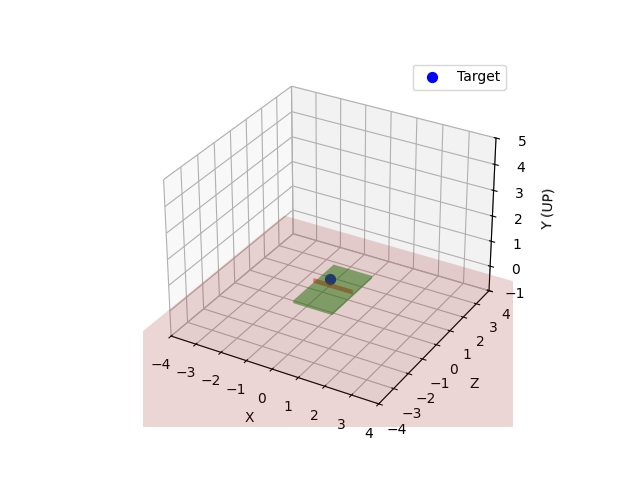

In [29]:
%matplotlib widget
trajectory = simulate_ball_trajectory(world, init_pos, candidate_velocity_B, init_spin, total_time=SECONDS, time_step=(1/FPS), verbose = True)
print("Done!")
trajectory.shape

from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import matplotlib.pyplot as plt

def draw_aabb_solid(ax, aabb : AABB, color='r', alpha=0.2):
    xmin, ymin, zmin = aabb.min_bound
    xmax, ymax, zmax = aabb.max_bound

    faces = [
        # abajo
        [(xmin,ymin,zmin), (xmax,ymin,zmin), (xmax,ymax,zmin), (xmin,ymax,zmin)],
        # arriba
        [(xmin,ymin,zmax), (xmax,ymin,zmax), (xmax,ymax,zmax), (xmin,ymax,zmax)],
        # lados
        [(xmin,ymin,zmin), (xmax,ymin,zmin), (xmax,ymin,zmax), (xmin,ymin,zmax)],
        [(xmin,ymax,zmin), (xmax,ymax,zmin), (xmax,ymax,zmax), (xmin,ymax,zmax)],
        [(xmin,ymin,zmin), (xmin,ymax,zmin), (xmin,ymax,zmax), (xmin,ymin,zmax)],
        [(xmax,ymin,zmin), (xmax,ymax,zmin), (xmax,ymax,zmax), (xmax,ymin,zmax)],
    ]

    faces_swapped = [
        [(x, z, y) for (x,y,z) in face]
        for face in faces
    ]

    box = Poly3DCollection(faces_swapped, alpha=alpha, facecolor=color)
    ax.add_collection3d(box)
    

import numpy as np
from matplotlib.animation import FuncAnimation

#if fig is already created, clear it
plt.clf()
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.set_xlabel('X')
ax.set_ylabel('Z')
ax.set_zlabel('Y (UP)')

# pelota (punto grande)
ball, = ax.plot([], [], [], 'o', markersize=8)

# trail corto
trail, = ax.plot([], [], [], lw=2)

TRAIL_LEN = 10  # 👈 ajusta esto (más chico = menos rastro)

def safe_limits(data):
    mn, mx = np.min(data), np.max(data)
    if mn == mx:
        return mn - 1, mx + 1
    return mn, mx
ax.set_xlim(-4,4)
ax.set_ylim(-4,4)
ax.set_zlim(-1,5)


draw_aabb_solid(ax, world["DESK"], color='green', alpha=0.3)
draw_aabb_solid(ax, world["NET"], color='red', alpha=0.3)
draw_aabb_solid(ax, world["FLOOR"], color='brown', alpha=0.1)
#draw the target
ax.scatter(target[0], target[2], target[1], color='blue', s=50, label='Target')
#draw evolution of the target guesses
# targets_x = [t[0] for t in targets]
# targets_y = [t[2] for t in targets]
# targets_z = [t[1] for t in targets]
# ax.plot(targets_x, targets_y, targets_z, color='cyan', marker='x', label='Target Guesses')

ax.legend()



time_text = ax.text2D(0.05, 0.95, '', transform=ax.transAxes)

def update(frame):
    # posición actual
    x = trajectory[frame, 0]
    y = trajectory[frame, 2]
    z = trajectory[frame, 1]

    ball.set_data([x], [y])
    ball.set_3d_properties([z])

    # trail corto
    start = max(0, frame - TRAIL_LEN)
    trail.set_data(
        trajectory[start:frame, 0],
        trajectory[start:frame, 2]
    )
    trail.set_3d_properties(
        trajectory[start:frame, 1]
    )
    # mostrar progreso
    time_text.set_text(f"Frame: {frame}/{len(trajectory)}")

    return ball, trail



#clear animation if it already exists
if 'ani' in globals():
    ani.event_source.stop()
ani = FuncAnimation(fig, update, frames=len(trajectory), interval=100,blit=False)
plt.show()

In [20]:
import torch

#create a basic n
INNER_LAYER_SIZE = 4
INNER_LAYER_QUANTITY = 2

INPUT_SIZE = 6 #pos(3) + vel(3)
OUTPUT_SIZE = 3 #vel(3)

class modelNN(torch.nn.Module):
    def __init__(self):
        super(modelNN, self).__init__()
        self.in_fc = torch.nn.Linear(INPUT_SIZE, INNER_LAYER_SIZE)
        self.hidden_fcs = torch.nn.ModuleList([torch.nn.Linear(INNER_LAYER_SIZE, INNER_LAYER_SIZE) for _ in range(INNER_LAYER_QUANTITY)])
        self.out_fc = torch.nn.Linear(INNER_LAYER_SIZE, OUTPUT_SIZE)

    def forward(self, x):
        x = torch.relu(self.in_fc(x))
        for hidden_fc in self.hidden_fcs:
            x = torch.relu(hidden_fc(x))
        return self.out_fc(x)

torch.manual_seed(42)
model = modelNN()

In [21]:
%%time
with torch.no_grad():
    #compute a simple run without training just to see the output
    x_in = torch.rand((INPUT_SIZE,))
    output = model(x_in)
    print("Input:", x_in)
    print("Output:", output)

Input: tensor([0.2979, 0.8035, 0.3813, 0.7860, 0.1115, 0.2477])
Output: tensor([-0.0315, -0.5825,  0.3436])
CPU times: total: 15.6 ms
Wall time: 72 ms
